# Clasificación de Reseñas de Películas con Naive Bayes y Pipelines

**Materiales desarrollados por Matías Barreto, 2026**

**Tecnicatura Superior en Ciencias de Datos e IA**
* **Nomenclatura Oficial:** Procesamiento de Lenguaje Natural
* **Nombre de Trabajo:** Laboratorio de PLN: Analítica, Textos y Cultura

---

## Objetivo
Aprender a diseñar flujos de trabajo eficientes de Machine Learning mediante Pipelines de Scikit-Learn, aplicando el clasificador probabilístico Naive Bayes.

## Resultados de aprendizaje
Al final de este notebook vas a poder:
1. Explicar el fundamento probabilístico del teorema de Bayes para clasificación de texto.
2. Construir Pipelines de Scikit-Learn para unificar la vectorización y el modelado en un único paso.
3. Comparar el rendimiento de clasificadores probabilísticos frente a modelos lineales.



## Terminología clave (Microglosario)

* **✦ Teorema de Bayes:** Principio de probabilidad que calcula la probabilidad posterior de un evento dada la probabilidad de evidencia previa.
* **✦ Naive Bayes (Bayes Iluso):** Clasificador probabilístico basado en el supuesto (iluso) de que todas las variables predictoras (palabras) son completamente independientes entre sí.
* **✦ Pipeline (Scikit-Learn):** Objeto que encadena secuencialmente múltiples pasos de preprocesamiento, extracción de características y modelado para automatizar el flujo de ML.



## 1. Importación de Librerías
Cargamos solo las herramientas que necesitamos para este cuaderno.


In [1]:
# Importamos librerías básicas
import numpy as np
import pandas as pd

# Vectorizador y clasificador
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

# Flujo y evaluación
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("OK: Librerías cargadas correctamente.")


OK: Librerías cargadas correctamente.


## 2. Nuestro Corpus Didáctico
Usaremos un conjunto pequeño de 20 reseñas de restaurantes en español rioplatense para poder ver exactamente qué hace el modelo en cada paso.


In [3]:
# 10 reseñas positivas (Etiqueta 1) y 10 reseñas negativas (Etiqueta 0)
reseñas = [
    "La milanesa a caballo estaba espectacular, muy recomendable.",
    "Qué buena onda la atención, volvería sin dudarlo.",
    "El flan con dulce de leche es lo más, quedé re contento.",
    "Excelente servicio, todo impecable y rápido.",
    "Me encantó el lugar, súper tranquilo y con buena música.",
    "La verdad que zafa y está bien de precio.",
    "Muy copado el ambiente, te sentís como en casa.",
    "El mejor asado que probé en mucho tiempo, de diez.",
    "Pedí empanadas y llegaron calentitas, re bien.",
    "Atención de primera, te explican todo con paciencia.",
    "El bife de chorizo llegó frío y duro, una decepción.",
    "Mucho quilombo, tardaron una banda en traer la cuenta.",
    "La verdad, la pizza dejaba bastante que desear.",
    "Pésima atención, el mozo tenía mala onda.",
    "No vuelvo más, carísimo y la comida era un desastre.",
    "Tardaron dos horas en entregar, llegó todo frío.",
    "El lugar es un desastre, sucio y con olor raro.",
    "Me cobraron de más y encima se hicieron los giles.",
    "La carne estaba pasada, casi no se podía comer.",
    "Malísima experiencia, no lo recomiendo para nada."
]

etiquetas = np.array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

# Creamos un DataFrame para ver los datos de forma ordenada
tabla_datos = pd.DataFrame({
    'texto': reseñas,
    'sentimiento': etiquetas
})

# Mostramos las primeras 5 filas
print("Primeras 5 reseñas del dataset:")
print(tabla_datos.head())


Primeras 5 reseñas del dataset:
                                               texto  sentimiento
0  La milanesa a caballo estaba espectacular, muy...            1
1  Qué buena onda la atención, volvería sin dudarlo.            1
2  El flan con dulce de leche es lo más, quedé re...            1
3       Excelente servicio, todo impecable y rápido.            1
4  Me encantó el lugar, súper tranquilo y con bue...            1


---
## 3. División en Entrenamiento y Prueba
Separamos los datos para poder evaluar el modelo con textos que nunca vio durante el entrenamiento.


In [5]:
# Separamos características (X) y etiquetas (y)
X = tabla_datos['texto'].to_numpy()
y = tabla_datos['sentimiento'].to_numpy()
# Dividimos: 70% para entrenar y 30% para probar
# 'stratify=y' asegura tener la misma cantidad de positivos/negativos en ambos lados
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print(f"Reseñas de entrenamiento: {len(X_train)}")
print(f"Reseñas de prueba: {len(X_test)}")


Reseñas de entrenamiento: 14
Reseñas de prueba: 6


---
## 4. Paso a Paso: Vectorización y Modelo Manual

Siguiendo el manual de código, vamos a **separar** los pasos de `fit` y `transform` para comprender bien el proceso antes de usar un Pipeline.

### ¿Qué significa Fit y Transform en TF-IDF?
- `fit`: Lee los textos de entrenamiento y arma el vocabulario (ej. asocia la palabra 'espectacular' al número 14).
- `transform`: Convierte cada frase en un vector de números usando ese vocabulario.


In [6]:
# Nota metodológica: Usamos un vocabulario pequeño de unigramas y bigramas
vectorizador = TfidfVectorizer(ngram_range=(1, 2), max_features=50)

# 1. 'fit' aprende el vocabulario a partir de los textos de entrenamiento
vectorizador.fit(X_train)

# 2. 'transform' convierte los textos de entrenamiento en números
X_train_vec = vectorizador.transform(X_train)

# 3. 'transform' en textos de prueba (¡Nota: AQUÍ NO SE USA FIT para no espiar datos!)
X_test_vec = vectorizador.transform(X_test)

print(f"Vocabulario aprendido: {len(vectorizador.get_feature_names_out())} palabras")
print("Primeras 10 palabras:", list(vectorizador.get_feature_names_out()[:10]))


Vocabulario aprendido: 50 palabras
Primeras 10 palabras: ['asado', 'banda', 'banda en', 'bastante', 'bastante que', 'bien', 'buena', 'caballo', 'caballo estaba', 'calentitas']


### Entrenamos a mano el Clasificador Naive Bayes
Ahora alimentamos a nuestro modelo MultinomialNB con los datos de entrenamiento vectorizados.


In [7]:
# Nota de herramienta: MultinomialNB es el clasificador Naive Bayes estándar para texto
modelo_nb = MultinomialNB()

# Entrenamos el modelo
modelo_nb.fit(X_train_vec, y_train)

# Hacemos predicciones sobre el conjunto de prueba
predicciones_manual = modelo_nb.predict(X_test_vec)

print("Predicciones realizadas:", predicciones_manual)
print("Etiquetas reales:      ", y_test)


Predicciones realizadas: [0 1 1 1 1 1]
Etiquetas reales:       [0 1 0 1 1 0]


---
## 5. El Camino Profesional: Usar un Pipeline

Hacer los pasos anteriores a mano puede llevar a errores (como aplicar `fit` en los datos de prueba por accidente). El **Pipeline** de Scikit-learn agrupa la vectorización y el clasificador en un solo objeto cómodo y seguro.


In [8]:
# Definimos el Pipeline encapsulando ambos pasos
pipeline_nb = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 2), max_features=50)),
    ('nb', MultinomialNB())
])

# Entrenamos todo el Pipeline con una sola llamada a fit()
# Nota metodológica: El pipeline hace automáticamente fit_transform en train y luego entrena el modelo
pipeline_nb.fit(X_train, y_train)

# Hacemos predicciones directas a partir de texto crudo
predicciones_pipeline = pipeline_nb.predict(X_test)

print("Predicciones con Pipeline:", predicciones_pipeline)


Predicciones con Pipeline: [0 1 1 1 1 1]


---
## 6. Evaluación de Resultados

### ¿Cómo leer el Reporte de Clasificación?
- **Precision (Precisión):** Si el modelo dice 'Positivo', ¿qué tan seguro es? (Pocos falsos positivos).
- **Recall (Exhaustividad):** De todas las reseñas positivas reales, ¿qué porcentaje atrapó el modelo? (Pocos falsos negativos).
- **F1-Score:** El balance promedio de ambas métricas.


In [9]:
# Mostramos el reporte completo
reporte = classification_report(
    y_test, 
    predicciones_pipeline, 
    target_names=['Negativo', 'Positivo']
)
print(reporte)


              precision    recall  f1-score   support

    Negativo       1.00      0.33      0.50         3
    Positivo       0.60      1.00      0.75         3

    accuracy                           0.67         6
   macro avg       0.80      0.67      0.62         6
weighted avg       0.80      0.67      0.62         6



### Matriz de Confusión
Graficamos la matriz para ver exactamente en qué se equivoca el modelo.


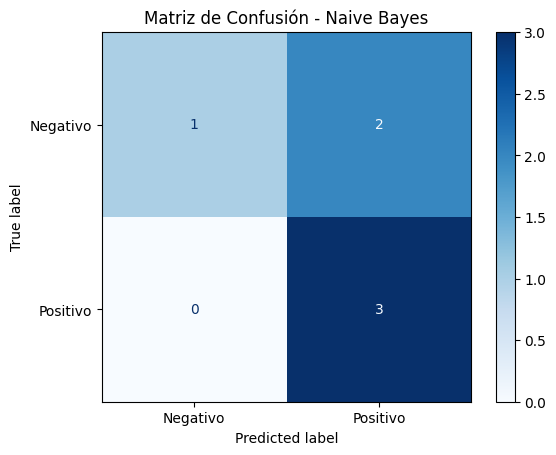

In [10]:
# Calculamos la matriz
matriz = confusion_matrix(y_test, predicciones_pipeline)

# La graficamos de forma interactiva
grafico = ConfusionMatrixDisplay(confusion_matrix=matriz, display_labels=['Negativo', 'Positivo'])
grafico.plot(cmap='Blues')
plt.title("Matriz de Confusión - Naive Bayes")
plt.show()


---
## 7. Probando con Textos Nuevos
Escribe tus propias frases para ver si el modelo las clasifica correctamente y qué nivel de probabilidad les asigna.


In [11]:
frases_nuevas = [
    "El lugar es una maravilla, muy recomendable.",
    "Una decepción total, tardaron muchísimo y la comida estaba fea."
]

# Predicción de etiquetas (0 o 1)
predicciones_nuevas = pipeline_nb.predict(frases_nuevas)

# Probabilidades porcentuales
probabilidades = pipeline_nb.predict_proba(frases_nuevas)

for i, frase in enumerate(frases_nuevas):
    sentido = "POSITIVO" if predicciones_nuevas[i] == 1 else "NEGATIVO"
    prob_pos = probabilidades[i][1] * 100
    prob_neg = probabilidades[i][0] * 100
    print(f"\nFrase: '{frase}'")
    print(f"Predicción: {sentido} | Confianza Positivo: {prob_pos:.1f}% | Confianza Negativo: {prob_neg:.1f}%")



Frase: 'El lugar es una maravilla, muy recomendable.'
Predicción: POSITIVO | Confianza Positivo: 55.3% | Confianza Negativo: 44.7%

Frase: 'Una decepción total, tardaron muchísimo y la comida estaba fea.'
Predicción: NEGATIVO | Confianza Positivo: 39.0% | Confianza Negativo: 61.0%


## Consigna de Lectura e Interpretación
**Pregunta para pensar:** Si agregas una frase nueva que dice *"La milanesa no estuvo muy buena"*, ¿cómo crees que la clasificará Naive Bayes? Recuerda que el modelo asume que las palabras son independientes y no entiende el sentido de la negación *"no... buena"* en conjunto. ¡Pruébalo en la celda de arriba y observa el resultado!
